In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import seaborn as sns

In [5]:
tips=sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


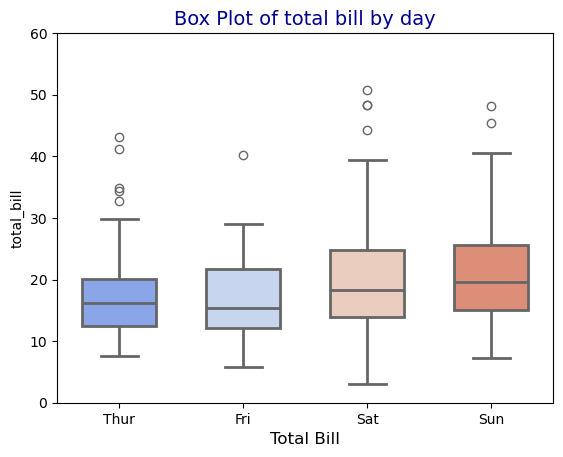

In [6]:
sns.boxplot(x='day',y='total_bill',data=tips,palette='coolwarm',width=0.6,linewidth=2,fliersize=6)
plt.ylim(0,60)
plt.title("Box Plot of total bill by day",fontsize=14,color='darkblue')
plt.xlabel("Day",fontsize=12)
plt.xlabel("Total Bill",fontsize=12)
plt.show()


In [14]:
# find number summery & out liers

Q1=tips["total_bill"].quantile(0.25)# median of first half data
Q2=tips["total_bill"].median() # median of data
Q3=tips["total_bill"].quantile(0.75) # median of second half data
IQR=Q3-Q1
lower_wishker=Q1-1.5 * IQR
upper_wishker=Q1+1.5 * IQR

minimum=tips["total_bill"].min()
maximum=tips["total_bill"].max()
outliers=tips[(tips["total_bill"] < lower_wishker)| (tips["total_bill"]>upper_wishker)]["total_bill"]
print("Box Plot  summary  for total bill by day")
print(f"Q1(25th percentile):{Q1:.2f}") #.2f --->formates number to 2 decimals
print(f"median Q2(50th percentile):{Q2:.2f}")
print(f" Q3 (75th percentile):{Q3:.2f}")
print(f"IQR:{IQR:.2f}")
print(f"Lower Whisker:{lower_wishker:.2f}")
print(f"Uower Whisker:{upper_wishker:.2f}")
print(f"mimimum value:{minimum:.2f}")
print(f"maximum value:{maximum:.2f}")
print(f"Outliers:{list(outliers)}")


Box Plot  summary  for total bill by day
Q1(25th percentile):13.35
median Q2(50th percentile):17.80
 Q3 (75th percentile):24.13
IQR:10.78
Lower Whisker:-2.82
Uower Whisker:29.52
mimimum value:3.07
maximum value:50.81
Outliers:[35.26, 39.42, 31.27, 30.4, 32.4, 34.81, 38.01, 48.27, 32.68, 34.83, 40.17, 44.3, 38.07, 29.93, 29.8, 34.3, 41.19, 29.85, 48.17, 31.71, 50.81, 31.85, 32.9, 34.63, 34.65, 45.35, 40.55, 30.46, 43.11, 38.73, 30.06, 48.33, 30.14, 32.83, 35.83]


## violin plot

<function matplotlib.pyplot.show(close=None, block=None)>

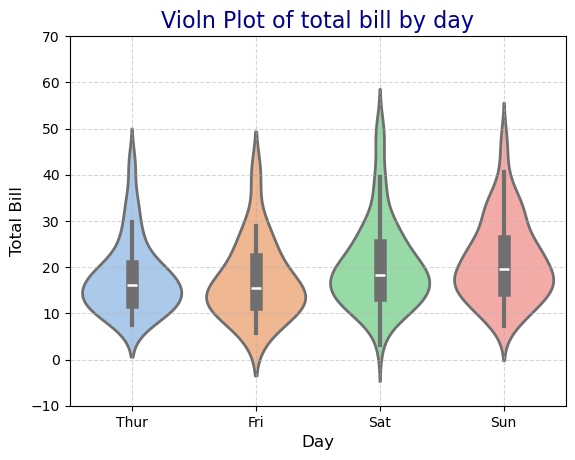

In [20]:

sns.violinplot(
     x='day',
     y='total_bill',
     data=tips,
     palette='pastel',
     inner='box',
     linewidth=2,
     scale='width'
)
plt.ylim(-10,70)
plt.xlabel("Day",fontsize=12)
plt.ylabel("Total Bill",fontsize=12)
plt.title("Violn Plot of total bill by day",fontsize=16,color='darkblue')
plt.grid(True,linestyle='--',alpha=0.5)
plt.show


## scatter plot

<function matplotlib.pyplot.show(close=None, block=None)>

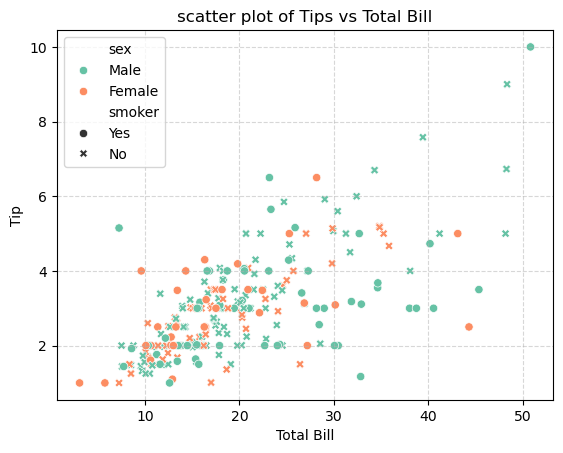

In [23]:
sns.scatterplot(
    x='total_bill',
    y='tip',
    data=tips,
    hue='sex',
    style='smoker',
    palette='Set2'
)
plt.title("scatter plot of Tips vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.grid(True,linestyle='--',alpha=0.5)
plt.show


## Line plot

<function matplotlib.pyplot.show(close=None, block=None)>

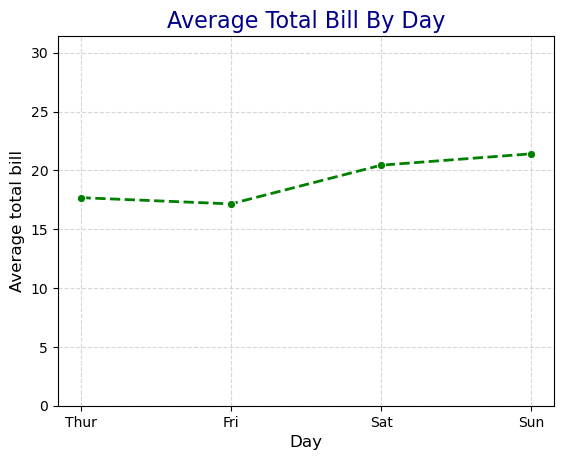

In [26]:
avg_total_bill=tips.groupby('day')['total_bill'].mean().reset_index()
sns.lineplot(
    x='day',
    y='total_bill',
    data=avg_total_bill,
    marker='o',
    linestyle='--',
    color='green',
    linewidth=2
)
plt.ylim(0,avg_total_bill['total_bill'].max()+10)
plt.title("Average Total Bill By Day",fontsize=16,color='darkblue')
plt.xlabel("Day",fontsize=12)
plt.ylabel("Average total bill",fontsize=12)
plt.grid(True,linestyle='--',alpha=0.5)
plt.show

## Bar Plot

<function matplotlib.pyplot.show(close=None, block=None)>

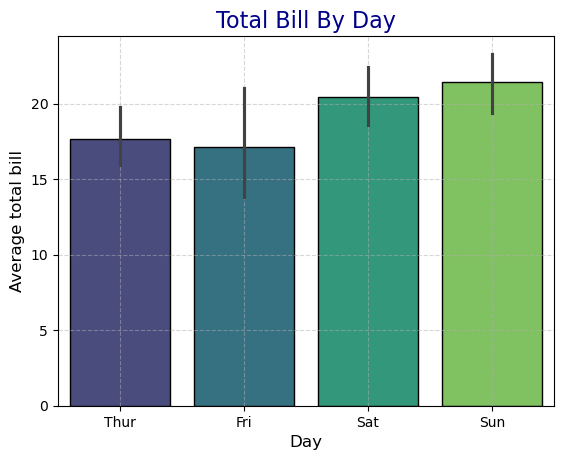

In [28]:
sns.barplot(
     x='day',
    y='total_bill',
    data=tips,
    palette='viridis',
    edgecolor='black'
)
plt.title("Total Bill By Day",fontsize=16,color='darkblue')
plt.xlabel("Day",fontsize=12)
plt.ylabel("Average total bill",fontsize=12)
plt.grid(True,linestyle='--',alpha=0.5)
plt.show

## Pair Plot

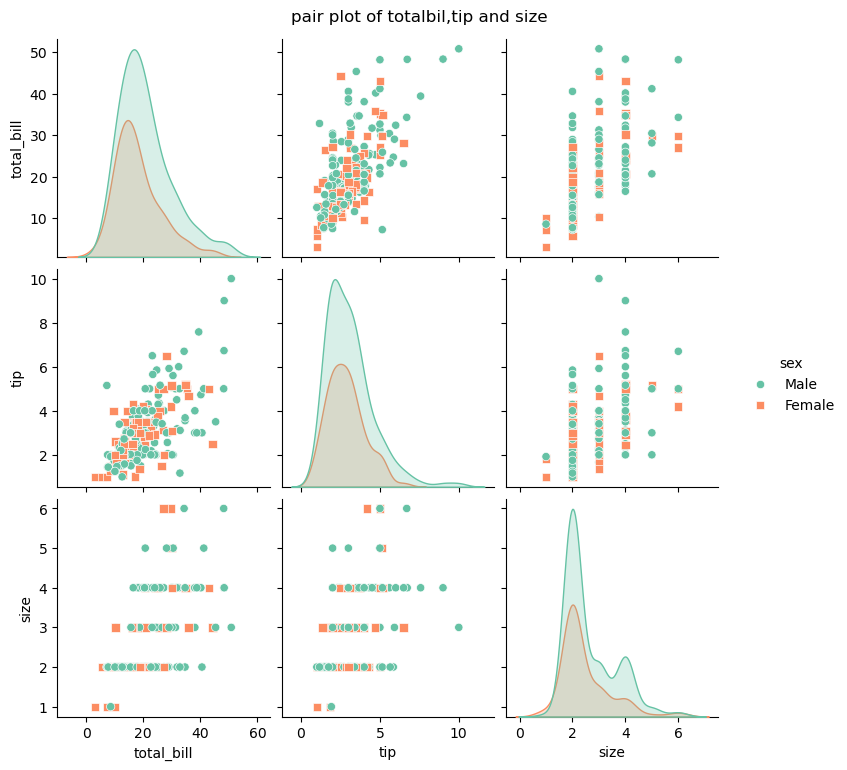

In [30]:
sns.pairplot(
    data=tips,
    vars=['total_bill','tip','size'],
    hue='sex',
    palette='Set2',
    diag_kind='kde',
    markers=['o','s']
)
plt.suptitle("pair plot of totalbil,tip and size",y=1.02)

#suptitle-->super title,means title for entire figure
plt.show()


## Heat Map

In [31]:
numeric_data=tips.select_dtypes(include=['number'])

corr=numeric_data.corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000
